# 📊 Exploratory Data Analysis (EDA) on Retail Sales Data

## Objective

The objective of this project is to analyze the Sample Superstore dataset to identify sales trends, profit distribution, regional performance, and generate business insights using Python.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [15]:
df = pd.read_csv("SampleSuperstore.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [16]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9993 non-null   object 
 1   Segment       9993 non-null   object 
 2   Country       9993 non-null   object 
 3   City          9993 non-null   object 
 4   State         9993 non-null   object 
 5   Postal Code   9993 non-null   int64  
 6   Region        9993 non-null   object 
 7   Category      9993 non-null   object 
 8   Sub-Category  9993 non-null   object 
 9   Sales         9993 non-null   float64
 10  Quantity      9993 non-null   int64  
 11  Discount      9993 non-null   float64
 12  Profit        9993 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.0+ KB


In [18]:
print("Rows and Columns:", df.shape)

Rows and Columns: (9993, 13)


In [19]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [20]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 17


In [21]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000
mean,55186.627539,229.856670,3.789753,0.156218,28.652464
std,32063.103801,623.276273,2.225149,0.206456,234.271411
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728000
50%,56301.000000,54.480000,3.000000,0.200000,8.662000
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Dataset Summary

- Dataset contains retail sales information.
- No missing values are present.
- The dataset includes sales, profit, quantity, and discount information.

# Sales by Category

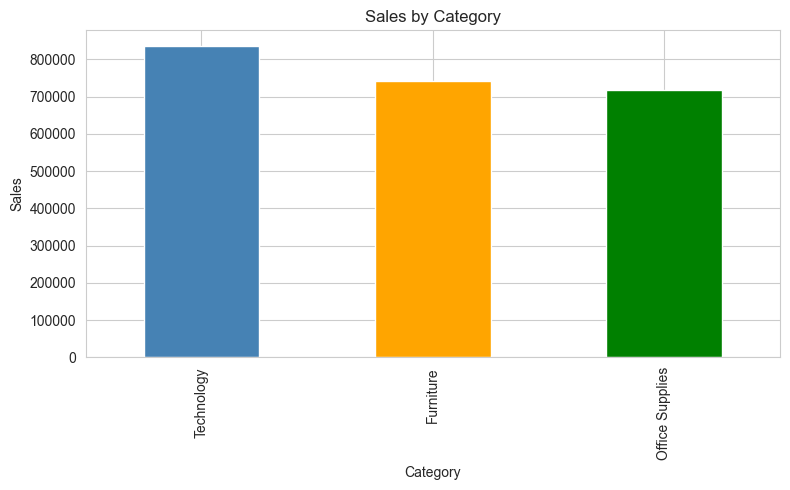

In [22]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar", color=["steelblue","orange","green"])

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("images/sales_by_category.png", dpi=300)

plt.show()

### Observation

- Technology has the highest sales.
- Furniture ranks second.
- Office Supplies has the lowest sales among the three categories.

# Profit by Category

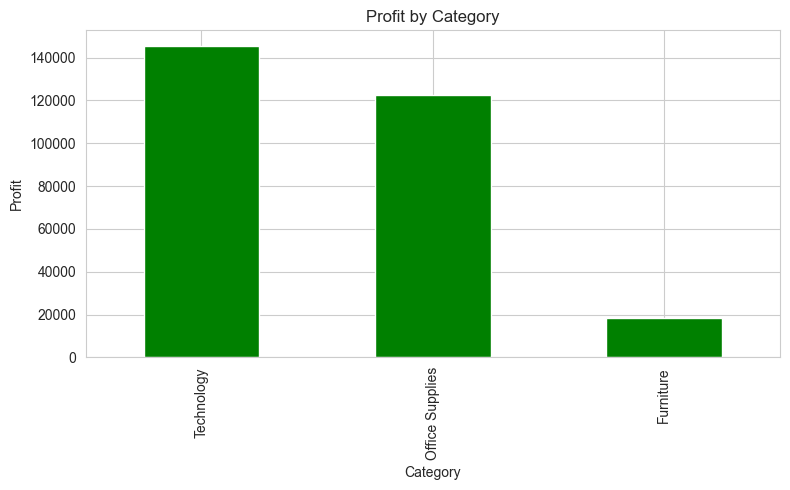

In [23]:
profit_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
profit_category.plot(kind="bar", color="green")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig("images/profit_by_category.png", dpi=300)

plt.show()

### Observation

- Technology generates the highest profit.
- Office Supplies also contribute positively.
- Furniture has comparatively lower profit.

# Sales by Region

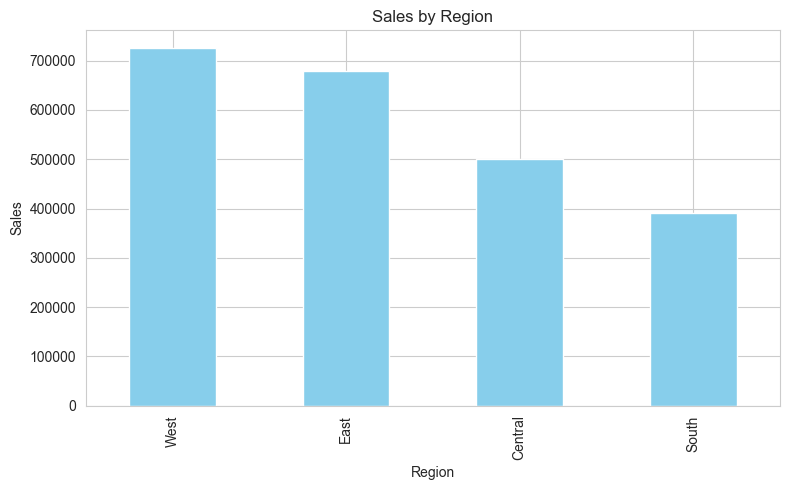

In [24]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar", color="skyblue")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("images/sales_by_region.png", dpi=300)

plt.show()

### Observation

- The West region records the highest sales.
- The East region also contributes significantly.
- The South region has comparatively lower sales.

# Top 10 States by Sales

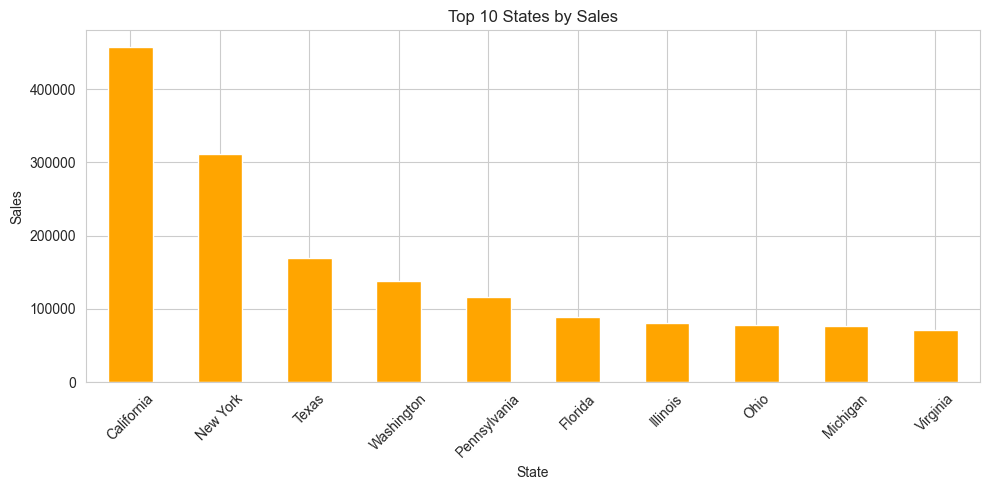

In [25]:
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind="bar", color="orange")

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("images/top_states_sales.png", dpi=300)

plt.show()

### Observation

- California records the highest sales.
- New York is the second highest contributor.
- These states play a significant role in revenue generation.

# Top 10 Sub-Categories by Sales

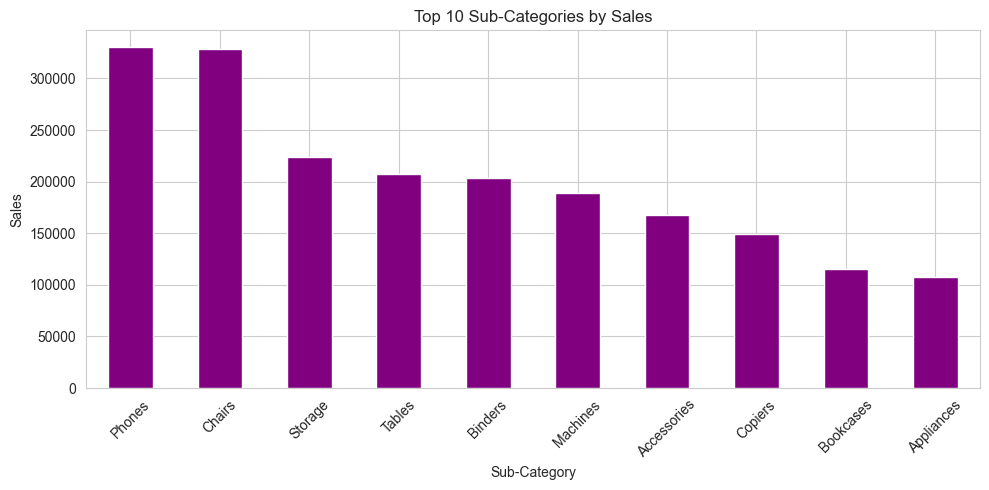

In [26]:
top_products = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar", color="purple")

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("images/top_subcategories.png", dpi=300)

plt.show()

### Observation

- Phones generate the highest sales.
- Chairs and Storage also contribute significantly.
- These products are among the best-selling categories.

# Correlation Heatmap

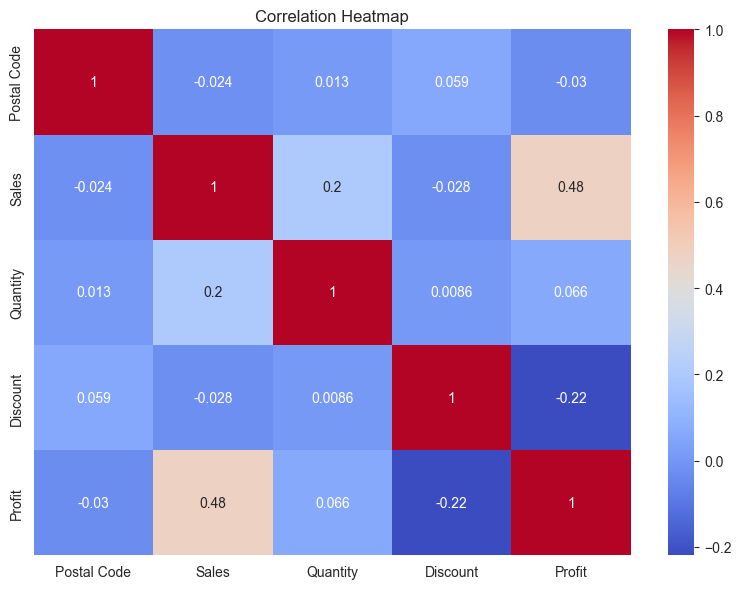

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("images/correlation_heatmap.png", dpi=300)

plt.show()

### Observation

- Sales and Profit have a positive correlation.
- Discount negatively affects Profit.
- Quantity has a weak relationship with Sales.

# Top 10 States by Profit

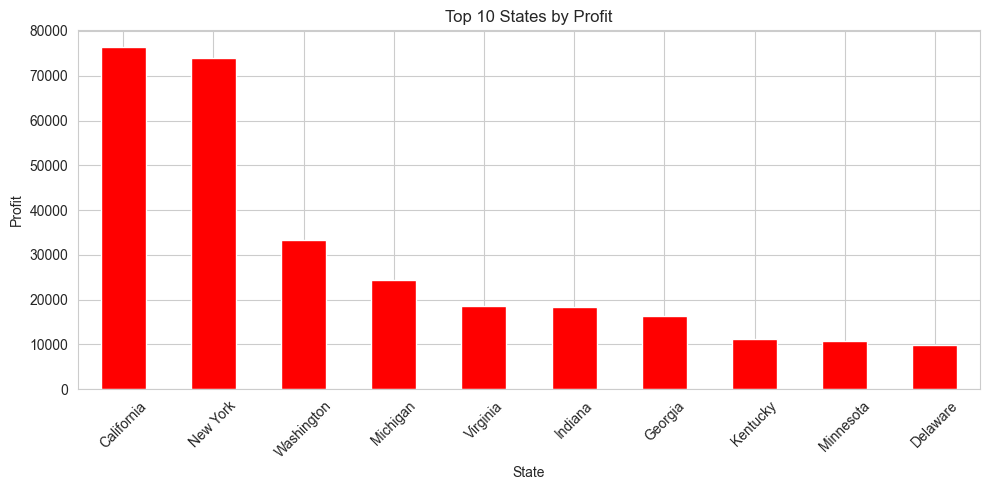

In [28]:
profit_state = df.groupby("State")["Profit"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
profit_state.plot(kind="bar", color="red")

plt.title("Top 10 States by Profit")
plt.xlabel("State")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("images/top_states_profit.png", dpi=300)

plt.show()

### Observation

- California and New York generate the highest profits.
- These states contribute significantly to the company's profitability.

# Conclusion

## Key Business Insights

- Technology is the highest-performing category in terms of sales and profit.
- The West region contributes the highest revenue.
- California is the top-performing state.
- Phones and Chairs are the most popular sub-categories.
- Discounts negatively impact profitability.

## Business Recommendations

- Increase inventory for high-demand products.
- Focus marketing efforts on top-performing regions.
- Review discount strategies to improve profitability.
- Strengthen sales strategies in lower-performing regions.